=== Aperçu des données ===
           Jan   Fév   Mar   Avr   Mai  Juin  Juil  Août   Sep   Oct   Nov  \
Paris     10.0  33.0  24.3  18.9   1.2   1.2  -2.7  29.6  19.0  23.3  -4.2   
Tokyo     28.3   3.5   2.3   2.3   7.2  16.0  12.3   6.6  19.5   0.6   6.7   
New York  13.2  26.4   3.0  15.6  18.7  -3.1  19.3   1.8  -2.4  33.0  33.6   
Sydney     7.2  -1.1  22.4  12.6  -0.1  14.8  -3.6  31.4   5.4  21.5   7.5   
Le Caire  16.9   2.4  33.8  26.0  32.6  30.8  18.9  31.9  -1.5   2.8  -3.2   
Moscow    10.5   5.9  28.1   9.3   6.2  16.7   0.6  27.1  -2.0  34.5  25.9   
Abidjan   -4.8  27.6  23.3  24.2  25.9  -2.0   9.3  -0.4  29.5  19.9   8.2   
Toronto    7.4   8.0  24.2  20.5  30.5  13.9  -0.2  23.5  25.4  17.5  25.8   
Dubai     15.9  12.1  -4.0  -0.7  -3.7  20.5   7.6  15.3  31.3   5.0  11.4   
Berlin     4.2  -1.9   6.6   1.4  32.2  27.3  20.3  29.9  27.1   2.5  30.7   

           Déc  
Paris     33.8  
Tokyo      9.7  
New York  27.3  
Sydney    15.8  
Le Caire   8.0  
Moscow     2

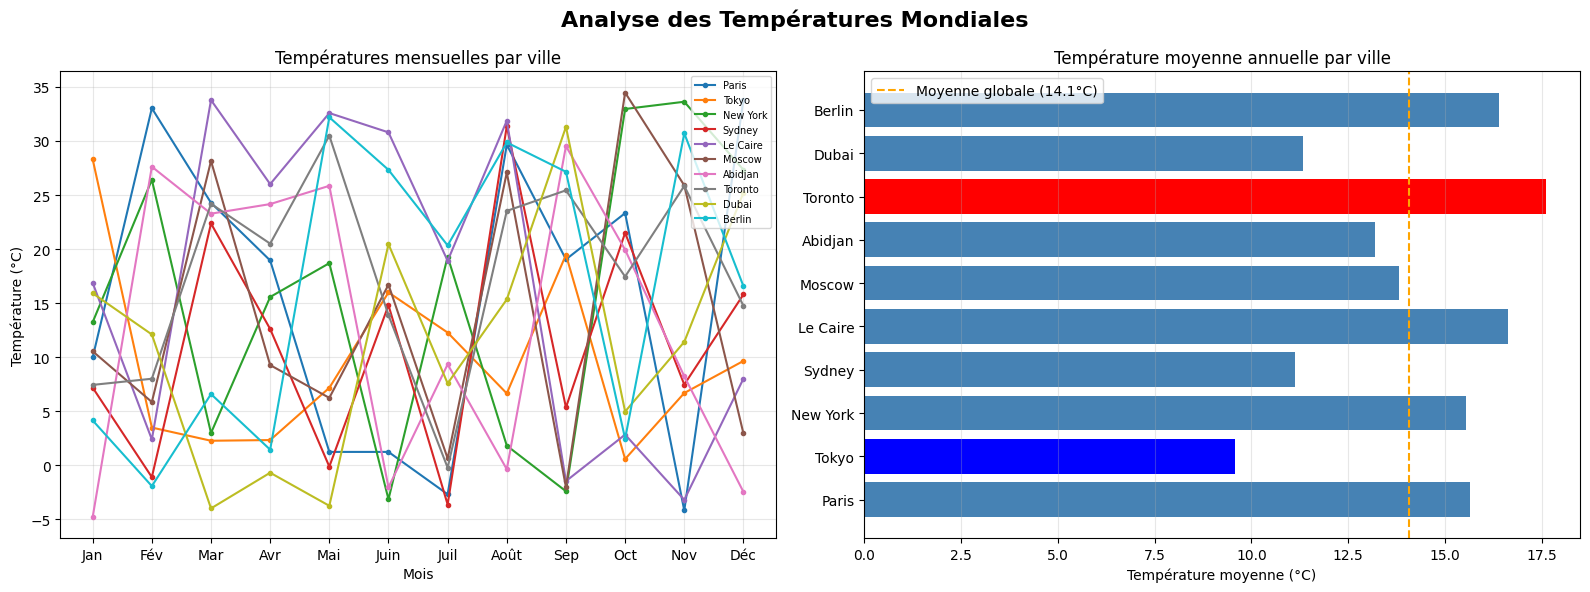


         RAPPORT DE SYNTHÈSE

📊 Données : 10 villes × 12 mois
   Plage de températures : -5°C à 35°C

🔥 Ville la plus chaude : Toronto
   → Moyenne annuelle : 17.61°C

❄️  Ville la plus froide : Tokyo
   → Moyenne annuelle : 9.57°C

🌍 Moyenne mondiale : 14.08°C

📈 Tendances observées :
   - Les températures varient aléatoirement (données synthétiques)
   - Écart entre ville la + chaude et la + froide : 8.03°C


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. PRÉPARATION DES DONNÉES ──────────────────────────────────────────

np.random.seed(42)  # Pour avoir les mêmes résultats à chaque exécution

# 10 villes, 12 mois, températures entre -5 et 35°C
temperature_data = np.random.uniform(low=-5, high=35, size=(10, 12))

villes = [
    "Paris", "Tokyo", "New York", "Sydney", "Le Caire",
    "Moscow", "Abidjan", "Toronto", "Dubai", "Berlin"
]

mois = [
    "Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
    "Juil", "Août", "Sep", "Oct", "Nov", "Déc"
]

# Conversion en DataFrame
df = pd.DataFrame(temperature_data, index=villes, columns=mois)

print("=== Aperçu des données ===")
print(df.round(1))


# ── 2. ANALYSE DES DONNÉES ──────────────────────────────────────────────

# Température moyenne annuelle par ville
moyenne_annuelle = df.mean(axis=1)

print("\n=== Température moyenne annuelle par ville ===")
print(moyenne_annuelle.round(2))

# Ville la plus chaude et la plus froide
ville_plus_chaude = moyenne_annuelle.idxmax()
ville_plus_froide = moyenne_annuelle.idxmin()

print(f"\n🔥 Ville la plus chaude : {ville_plus_chaude} ({moyenne_annuelle[ville_plus_chaude]:.2f}°C)")
print(f"❄️  Ville la plus froide : {ville_plus_froide} ({moyenne_annuelle[ville_plus_froide]:.2f}°C)")


# ── 3. VISUALISATION ────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Analyse des Températures Mondiales", fontsize=16, fontweight="bold")

# Graphique 1 : Évolution mensuelle pour chaque ville
for ville in villes:
    axes[0].plot(mois, df.loc[ville], marker="o", markersize=3, label=ville)

axes[0].set_title("Températures mensuelles par ville")
axes[0].set_xlabel("Mois")
axes[0].set_ylabel("Température (°C)")
axes[0].legend(loc="upper right", fontsize=7)
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Moyenne annuelle par ville (barres horizontales)
couleurs = ["red" if v == ville_plus_chaude else "blue" if v == ville_plus_froide
            else "steelblue" for v in villes]

axes[1].barh(villes, moyenne_annuelle, color=couleurs)
axes[1].set_title("Température moyenne annuelle par ville")
axes[1].set_xlabel("Température moyenne (°C)")
axes[1].axvline(x=moyenne_annuelle.mean(), color="orange",
                linestyle="--", label=f"Moyenne globale ({moyenne_annuelle.mean():.1f}°C)")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("temperatures_mondiales.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 4. RAPPORT DE SYNTHÈSE ──────────────────────────────────────────────

print("\n" + "="*50)
print("         RAPPORT DE SYNTHÈSE")
print("="*50)
print(f"\n📊 Données : 10 villes × 12 mois")
print(f"   Plage de températures : -5°C à 35°C\n")
print(f"🔥 Ville la plus chaude : {ville_plus_chaude}")
print(f"   → Moyenne annuelle : {moyenne_annuelle[ville_plus_chaude]:.2f}°C")
print(f"\n❄️  Ville la plus froide : {ville_plus_froide}")
print(f"   → Moyenne annuelle : {moyenne_annuelle[ville_plus_froide]:.2f}°C")
print(f"\n🌍 Moyenne mondiale : {moyenne_annuelle.mean():.2f}°C")
print(f"\n📈 Tendances observées :")
print(f"   - Les températures varient aléatoirement (données synthétiques)")
print(f"   - Écart entre ville la + chaude et la + froide : "
      f"{moyenne_annuelle[ville_plus_chaude] - moyenne_annuelle[ville_plus_froide]:.2f}°C")
print("="*50)

In [5]:
!pip install matplotlib


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
